# ICU LOS Pipeline

## Full Pipeline Table of Contents

1. [Preprocess Pipeline](#Preprocess-Pipeline)
2. [Data Preparation Pipeline](#Data-Preparation-Pipeline)
3. [Training, Validation, and Hyperparameter Tuning](#Training-Validation-and-Hyperparameter-Tuning)

## Preprocess Pipeline

**Objective:** Transform the raw MIMIC-III ICU tables into a compact, ICU-stay-level feature table that can be consumed by the preparation and training stages.

[Back to Full Pipeline Table of Contents](#Full-Pipeline-Table-of-Contents)

### Table of Contents

1. [Objectives](#Objectives)
2. [Distributed BigQuery Architecture](#Distributed-BigQuery-Architecture)
3. [Raw Data Loading](#Raw-Data-Loading)
4. [Temporal Filtering](#Temporal-Filtering)
5. [Feature Engineering](#Feature-Engineering)
6. [Contextual Features](#Contextual-Features)
7. [Leakage Prevention](#Leakage-Prevention)
8. [Generated Outputs](#Generated-Outputs)

### Objectives

The preprocessing stage converts the raw ICU event data into one modeling row per `ICUSTAY_ID`.

The main goals are to:

- define `LOS` as the prediction target,
- keep only information available at the beginning of the ICU stay,
- summarize high-volume clinical events into tabular features,
- add demographic and admission context,
- generate reproducible feature tables and quality-control outputs.

[Back to Table of Contents](#Table-of-Contents)

### Distributed BigQuery Architecture

The project uses BigQuery as the main preprocessing engine because the raw clinical event tables are too large to process comfortably in memory with pandas. The Python wrapper in `src/preprocessing/bigquery_preprocess.py` reads a YAML configuration, loads raw CSVs from Google Cloud Storage when needed, renders the SQL template, runs the query in BigQuery, and optionally exports/downloads the resulting feature table.

The local pandas implementation in `src/preprocessing/preprocess.py` mirrors the same logic for smaller samples or local validation, while the BigQuery pipeline is the production path for the full dataset.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
from pathlib import Path
import sys
import yaml
import pandas as pd

NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

BIGQUERY_CONFIG_PATH = ROOT_DIR / "configs" / "bigquery_7_tables.yaml"
BIGQUERY_SQL_TEMPLATE = ROOT_DIR / "sql" / "bigquery_preprocessing_7_tables.sql"
LOCAL_PREPROCESS_CONFIG_PATH = ROOT_DIR / "configs" / "preprocessing.yaml"

with BIGQUERY_CONFIG_PATH.open("r", encoding="utf-8") as file:
    bigquery_config = yaml.safe_load(file)

with LOCAL_PREPROCESS_CONFIG_PATH.open("r", encoding="utf-8") as file:
    local_preprocess_config = yaml.safe_load(file)

print(f"Project root: {ROOT_DIR}")
print(f"BigQuery config: {BIGQUERY_CONFIG_PATH.relative_to(ROOT_DIR)}")
print(f"SQL template: {BIGQUERY_SQL_TEMPLATE.relative_to(ROOT_DIR)}")
print(f"Prediction window: {bigquery_config['window_hours']} hours")

In [ ]:
architecture_summary = pd.DataFrame(
    [
        ("Cloud Storage", f"gs://{bigquery_config['gcs']['bucket']}/{bigquery_config['gcs']['raw_prefix']}/", "Stores the raw compressed CSV files."),
        ("BigQuery raw tables", bigquery_config["dataset_id"], "Holds typed copies of the source tables."),
        ("SQL preprocessing", BIGQUERY_SQL_TEMPLATE.name, "Filters, joins, aggregates, pivots, and writes feature tables."),
        ("Feature export", bigquery_config["outputs"]["features_export_uri"], "Exports the final ICU-stay-level feature table."),
    ],
    columns=["Layer", "Project object", "Role"],
)

display(architecture_summary)

### Raw Data Loading

The raw tables are configured in `configs/bigquery_7_tables.yaml`. This final experiment uses ICU stays, chart events, item metadata, patient demographics, admissions, lab events, and lab-item metadata.

The loader applies explicit BigQuery schemas before running the SQL transformation, which keeps column types stable across repeated runs.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
raw_tables = pd.DataFrame(
    [
        {
            "table_key": table_key,
            "bigquery_table": table_name,
            "raw_file": bigquery_config["raw_files"].get(table_key),
        }
        for table_key, table_name in bigquery_config["tables"].items()
    ]
)

display(raw_tables)

In [ ]:
load_command = (
    "python -m src.preprocessing.bigquery_preprocess "
    "--config configs/bigquery_7_tables.yaml "
    "--sql-template sql/bigquery_preprocessing_7_tables.sql "
    "--load-raw --export --download data/processed/bigquery_features_7_tables"
)

print(load_command)

### Temporal Filtering

The model is designed to make an early ICU length-of-stay prediction. To simulate that setting, time-dependent clinical measurements are restricted to the first `window_hours` after `INTIME`.

For the 7-table pipeline, this filter is applied to:

- `CHARTEVENTS`, joined by `ICUSTAY_ID`,
- `LABEVENTS`, joined through `HADM_ID` and mapped back to the ICU stay.

Events before ICU admission and events after the prediction window are excluded from the feature table.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
window_hours = bigquery_config["window_hours"]

temporal_rules = pd.DataFrame(
    [
        ("Prediction window start", "INTIME"),
        ("Prediction window end", f"INTIME + {window_hours} hours"),
        ("Included events", "EVENT_TIME >= INTIME and EVENT_TIME <= window end"),
        ("Excluded events", "Measurements before ICU admission or after the first 24h"),
    ],
    columns=["Rule", "Definition"],
)

display(temporal_rules)

### Feature Engineering

The high-volume event tables start in long format, with multiple measurements per stay, item, and timestamp. The preprocessing SQL first selects the most frequent numeric items inside the prediction window, then aggregates each selected item per ICU stay.

For each selected chart or lab item, the pipeline creates:

- `mean`, `min`, `max`, `std`, `count`, and `last`.

The 7-table configuration keeps the top chart items and top lab items separately, producing feature names such as `chart_<ITEMID>_mean` and `lab_<ITEMID>_last`.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
feature_engineering_summary = pd.DataFrame(
    [
        ("Chart events", "CHARTEVENTS", bigquery_config["top_n_chart_items"], "chart_<ITEMID>_<stat>"),
        ("Lab events", "LABEVENTS", bigquery_config["top_n_lab_items"], "lab_<ITEMID>_<stat>"),
    ],
    columns=["Feature family", "Source table", "Selected items", "Generated column pattern"],
)

aggregation_stats = ["mean", "min", "max", "std", "count", "last"]

display(feature_engineering_summary)
print("Aggregation statistics:", aggregation_stats)

### Contextual Features

In addition to event-based measurements, the pipeline adds context that is available at admission or at the start of the ICU stay. These variables help describe the patient and the admission without using future discharge information.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
contextual_features = pd.DataFrame(
    [
        ("ICUSTAYS", "DBSOURCE, FIRST_CAREUNIT, LAST_CAREUNIT"),
        ("PATIENTS", "GENDER, AGE"),
        ("ADMISSIONS", "ADMISSION_TYPE, ADMISSION_LOCATION, INSURANCE, LANGUAGE, RELIGION, MARITAL_STATUS, ETHNICITY, HAS_CHARTEVENTS_DATA, ED_LOS_HOURS"),
    ],
    columns=["Source", "Context features"],
)

display(contextual_features)

### Leakage Prevention

Preprocessing avoids temporal leakage by using only measurements from the first 24 hours of the ICU stay. It also avoids target leakage by not exposing discharge or outcome variables as predictors.

The target remains `LOS`, but variables that directly reveal the end of the stay, discharge status, or death outcome are not included in the exported feature matrix.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
target_col = "LOS"
id_cols = ["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID"]
leakage_excluded_cols = [
    "OUTTIME",
    "DISCHTIME",
    "DEATHTIME",
    "DISCHARGE_LOCATION",
    "HOSPITAL_EXPIRE_FLAG",
    "DOD",
    "DOD_HOSP",
    "DOD_SSN",
]

leakage_policy = pd.DataFrame(
    [
        ("Prediction target", target_col, "Kept as target only."),
        ("Identifiers", ", ".join(id_cols), "Kept for traceability and grouped splitting, not as model predictors."),
        ("Excluded future/outcome fields", ", ".join(leakage_excluded_cols), "Removed from feature generation."),
    ],
    columns=["Category", "Columns", "Use"],
)

display(leakage_policy)

### Generated Outputs

The preprocessing stage writes BigQuery tables for selected items, the final feature table, and quality-control metrics. The exported CSV is the input for the Data Preparation Pipeline, where train/test splitting, imputation, scaling, and encoding are performed.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
generated_outputs = pd.DataFrame(
    [
        ("Selected chart items", bigquery_config["outputs"]["selected_items_table"]),
        ("Selected lab items", bigquery_config["outputs"]["selected_lab_items_table"]),
        ("Feature table", bigquery_config["outputs"]["features_table"]),
        ("Quality report", bigquery_config["outputs"]["quality_report_table"]),
        ("Feature export URI", bigquery_config["outputs"]["features_export_uri"]),
    ],
    columns=["Output", "Location or table"],
)

display(generated_outputs)

In [ ]:
expected_preparation_input = ROOT_DIR / "data" / "processed" / "7tables_24h" / "features.csv"
local_export_dir = ROOT_DIR / "data" / "processed" / "bigquery_features_7_tables"

local_output_check = pd.DataFrame(
    [
        ("Preparation input expected by this notebook", expected_preparation_input, expected_preparation_input.exists()),
        ("Downloaded BigQuery export directory", local_export_dir, local_export_dir.exists()),
    ],
    columns=["Artifact", "Path", "Exists locally"],
)

display(local_output_check)

## Data Preparation Pipeline
[Back to Full Pipeline Table of Contents](#Full-Pipeline-Table-of-Contents)

### Table of Contents
  
1. [Goals and Objectives](#Goals-and-Objectives)
2. [Configuration and Imports](#Configuration-and-Imports)  
3. [Load Engineered Features](#Load-Engineered-Features)  
4. [Initial Data Audit](#Initial-Data-Audit)  
5. [Feature Type Detection](#Feature-Type-Detection)  
6. [Grouped Train/Test Split](#Grouped-TrainTest-Split)  
7. [Preprocessing Strategy](#Preprocessing-Strategy)  
8. [Build Preparation Pipeline](#Build-Preparation-Pipeline)  
9. [Fit and Transform Data](#Fit-and-Transform-Data)  
10. [Export Prepared Datasets](#Export-Prepared-Datasets)  
11. [Save Preparation Artifacts](#Save-Preparation-Artifacts)  
12. [Final Remarks](#Final-Remarks)

### Goals and Objectives

**Objective:** Prepare the engineered ICU dataset for machine learning by:

- preventing patient leakage,
- creating train/test splits,
- imputing missing values,
- scaling numeric variables,
- encoding categorical variables,
- exporting ML-ready datasets and preprocessing artifacts.

[Back to Table of Contents](#Table-of-Contents)

### Configuration and Imports
[Back to Table of Contents](#Table-of-Contents)

In [ ]:
import os
print(os.getcwd())

c:\Users\catar\OneDrive\Ambiente de Trabalho\fcup\3 ano\2\CDLE\ICU-LengthOfStay-Prediction\notebooks


In [ ]:
from pathlib import Path
import sys

ROOT_DIR = Path.cwd().parent

if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

print(ROOT_DIR)

c:\Users\catar\OneDrive\Ambiente de Trabalho\fcup\3 ano\2\CDLE\ICU-LengthOfStay-Prediction


In [ ]:
import pandas as pd
from pathlib import Path
import joblib
import logging;

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

ID_COLS = ["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID"]
TARGET_COL = "LOS"

ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data" / "processed"
MODELS_DIR = ROOT_DIR / "models"

FEATURE_SET = "7tables"
WINDOW_SIZE = "24h"
EXPERIMENT_NAME = f"{FEATURE_SET}_{WINDOW_SIZE}"

EXPERIMENT_DATA_DIR = DATA_DIR / EXPERIMENT_NAME
EXPERIMENT_DATA_DIR.mkdir(parents=True, exist_ok=True)

INPUT_PATH = EXPERIMENT_DATA_DIR / f"features.csv"
TRAIN_PATH = EXPERIMENT_DATA_DIR / f"train.csv"
TEST_PATH = EXPERIMENT_DATA_DIR / f"test.csv"
PREPROCESSOR_PATH = EXPERIMENT_DATA_DIR / f"preprocessor.joblib"

### Load Engineered Features

The preparation stage starts from the engineered ICU feature table generated during preprocessing.

Each row represents a single ICU stay (`ICUSTAY_ID`).

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
features = pd.read_csv(INPUT_PATH)

print("Dataset shape:", features.shape)

display(features.head(2))

Dataset shape: (59125, 318)


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,DBSOURCE,FIRST_CAREUNIT,LAST_CAREUNIT,LOS,GENDER,AGE,ADMISSION_TYPE,...,item_220051_max,item_220051_std,item_220051_count,item_220051_last,item_220179_mean,item_220179_min,item_220179_max,item_220179_std,item_220179_count,item_220179_last
0,45176,186422,238503,METAVISION,MICU,MICU,1.0551,M,62,EMERGENCY,...,NaN,NaN,NaN,NaN,133.285714,111.0,157.0,14.973787,21.0,140.0
1,42929,174715,228746,METAVISION,MICU,MICU,1.7171,F,82,EMERGENCY,...,NaN,NaN,NaN,NaN,100.000000,84.0,115.0,8.079154,23.0,98.0


### Initial Dataset Audit

Before splitting and transforming the dataset, it is important to validate:

- dataset dimensions,
- identifier availability,
- target availability,
- missing-value patterns,
- approximate feature composition.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
print("Rows:", len(features))
print("Columns:", features.shape[1])

for col in ID_COLS + [TARGET_COL]:
    print(f"{col}: {col in features.columns}")

missing_ratio = (
    features.isna()
    .mean()
    .sort_values(ascending=False)
)

display(missing_ratio.head(20).rename("missing_ratio").to_frame())

Rows: 59125
Columns: 318
SUBJECT_ID: True
HADM_ID: True
ICUSTAY_ID: True
LOS: True


,missing_ratio
item_676_std,0.916245
item_679_std,0.916245
item_676_mean,0.913116
item_676_last,0.913116
item_676_count,0.913116
item_676_max,0.913116
item_676_min,0.913116
item_679_last,0.913099
item_679_mean,0.913099
item_679_min,0.913099


### Feature Type Detection

The preprocessing pipeline separates features into:

- numeric variables,
- categorical variables.

This distinction is required because each feature type uses a different preprocessing strategy.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
feature_cols = [
    col for col in features.columns
    if col not in ID_COLS + [TARGET_COL]
]

categorical_cols = (
    features[feature_cols]
    .select_dtypes(include=["object", "string", "category"])
    .columns
    .tolist()
)

numeric_cols = [
    col for col in feature_cols
    if col not in categorical_cols
]

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))

Numeric columns: 303
Categorical columns: 11


### Grouped Train/Test Split

The dataset is split using `GroupShuffleSplit` with `SUBJECT_ID` as the grouping variable.

This prevents patient leakage by ensuring that the same patient cannot appear in both training and test datasets.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, test_idx = next(
    splitter.split(features, groups=features["SUBJECT_ID"])
)

train = features.iloc[train_idx].copy()
test = features.iloc[test_idx].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (47333, 318)
Test shape: (11792, 318)


### Leakage Validation

The overlap between train and test patients is verified to confirm that grouped splitting worked correctly.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
train_subjects = set(train["SUBJECT_ID"].unique())
test_subjects = set(test["SUBJECT_ID"].unique())

overlap = train_subjects.intersection(test_subjects)

print("Train subjects:", len(train_subjects))
print("Test subjects:", len(test_subjects))
print("Overlap:", len(overlap))

Train subjects: 35992
Test subjects: 8998
Overlap: 0


### Preprocessing Strategy

+ #### Numeric Features

    - median imputation,
    - missing indicators,
    - standard scaling.

+ #### Categorical Features

    - most frequent imputation,
    - one-hot encoding.

The preprocessing pipeline is fitted only on the training set to prevent data leakage.

[Back to Table of Contents](#Table-of-Contents)

### Build Preparation Pipeline
[Back to Table of Contents](#Table-of-Contents)

In [ ]:
transformers = []

if numeric_cols:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]
    )

    transformers.append(("num", numeric_pipeline, numeric_cols))

if categorical_cols:
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )),
        ]
    )

    transformers.append(("cat", categorical_pipeline, categorical_cols))

preprocessor = ColumnTransformer(
    transformers=transformers
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### Fit and Transform Data

The preprocessing pipeline is fitted only on the training data.

The learned transformations are then applied to both train and test datasets.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
train_values = preprocessor.fit_transform(
    train[feature_cols]
)

test_values = preprocessor.transform(
    test[feature_cols]
)

transformed_cols = [
    col.replace("num__", "").replace("cat__", "")
    for col in preprocessor.get_feature_names_out()
]

train_out = pd.concat(
    [
        train[ID_COLS + [TARGET_COL]].reset_index(drop=True),
        pd.DataFrame(train_values, columns=transformed_cols),
    ],
    axis=1,
)

test_out = pd.concat(
    [
        test[ID_COLS + [TARGET_COL]].reset_index(drop=True),
        pd.DataFrame(test_values, columns=transformed_cols),
    ],
    axis=1,
)

print("Prepared train shape:", train_out.shape)
print("Prepared test shape:", test_out.shape)

Prepared train shape: (47333, 780)
Prepared test shape: (11792, 780)


### Export Prepared Datasets
[Back to Table of Contents](#Table-of-Contents)

In [ ]:
train_out.to_csv(TRAIN_PATH, index=False)
test_out.to_csv(TEST_PATH, index=False)

print("Saved:", TRAIN_PATH)
print("Saved:", TEST_PATH)

Saved: ..\data\processed\train.csv
Saved: ..\data\processed\test.csv


### Save Preparation Artifacts

The fitted preprocessing pipeline is saved to support:

- reproducibility,
- consistent future inference,
- deployment compatibility.

[Back to Table of Contents](#Table-of-Contents)

In [ ]:
joblib.dump(preprocessor, PREPROCESSOR_PATH)

print("Saved:", PREPROCESSOR_PATH)

Saved: ..\models\preprocessor.joblib


### Final Remarks

The preparation stage produced:

- leakage-safe train/test datasets,
- fully numeric ML-ready feature matrices,
- a reusable preprocessing pipeline artifact.

These outputs are now ready for model training, benchmarking, tuning, and evaluation.

[Back to Table of Contents](#Table-of-Contents)

## Training, Validation, and Hyperparameter Tuning

**Objective:** Train, compare, tune, evaluate, and interpret regression models for ICU **Length of Stay (LOS)** prediction using the preprocessed `train.csv` and `test.csv` datasets.

[Back to Full Pipeline Table of Contents](#Full-Pipeline-Table-of-Contents)

### Table of Contents

1. [Project Context](#Project-Context)  
2. [Notebook Goals](#Notebook-Goals)  
3. [Configuration and Imports](#Configuration-and-Imports)  
4. [Load Training and Test Data](#Load-Training-and-Test-Data)  
5. [Initial Data Audit](#Initial-Data-Audit)  
6. [Feature and Target Definition](#Feature-and-Target-Definition)  
7. [Cross-Validation Strategy](#Cross-Validation-Strategy)  
8. [Baseline Models](#Baseline-Models)  
9. [Cross-Validated Benchmarking](#Cross-Validated-Benchmarking)  
10. [Fit Baseline Models and Evaluate on Test Set](#Fit-Baseline-Models-and-Evaluate-on-Test-Set)  
11. [Hyperparameter Tuning with Optuna](#Hyperparameter-Tuning-with-Optuna)  
12. [Final Model Training and Test Evaluation](#Final-Model-Training-and-Test-Evaluation)  
13. [Model Interpretation](#Model-Interpretation)  
14. [Save Results and Artifacts](#Save-Results-and-Artifacts)  
15. [Final Remarks](#Final-Remarks)

### Project Context

The target variable is **`LOS`**, representing ICU **Length of Stay**.  
Each row corresponds to a single **`ICUSTAY_ID`**, meaning that the dataset is already structured at the ICU-stay level.

The preprocessing stage has already:

- restricted the time-dependent data to the first **24 hours** of the ICU stay,
- aggregated ICU event measurements into tabular features,
- added demographic and admission context,
- encoded categorical variables,
- produced train/test CSV files.


### Notebook Goals

This notebook is designed to support a strong and defendable modeling phase.  
The workflow includes:

- loading the prepared datasets,
- verifying data integrity,
- defining features and target,
- benchmarking multiple regression models,
- preventing patient leakage during validation with **GroupKFold**,
- optimizing selected models with **Optuna**,
- evaluating the final model on the held-out test set,
- interpreting model behavior,
- saving the main outputs for reporting and reproducibility.

### Configuration and Imports

In [ ]:
from pathlib import Path
import warnings
import json
import time
import os
import ast
import joblib

import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    median_absolute_error
)

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt

try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

RANDOM_STATE = 42
N_SPLITS = 5
TARGET_COL = "LOS"
ID_COLS = ["SUBJECT_ID", "HADM_ID", "ICUSTAY_ID"]

TRAIN_PATH = r"C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\data\processed\train.csv"
TEST_PATH = r"C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\data\processed\test.csv"

RESULTS_DIR = r"C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\results"
MODELS_DIR = r"C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\models"

print(f"Optuna available: {OPTUNA_AVAILABLE}")
print(f"Expected train path: {TRAIN_PATH}")
print(f"Expected test path:  {TEST_PATH}")

Optuna available: True
Expected train path: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\data\processed\train.csv
Expected test path:  C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\data\processed\test.csv


### Load Training and Test Data

- `LOS` is the regression target,
- ID columns are still present for traceability but should not be used as predictors.

In [ ]:
# Load Training and Test Data

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

display(train_df.head(2))
display(test_df.head(2))

Train shape: (47333, 780)
Test shape:  (11792, 780)


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,LOS,AGE,HAS_CHARTEVENTS_DATA,ED_LOS_HOURS,item_113_mean,item_113_min,item_113_max,item_113_std,item_113_count,item_113_last,item_5813_mean,item_5813_min,item_5813_max,item_5813_std,item_5813_count,item_5813_last,item_581_mean,item_581_min,item_581_max,item_581_std,item_581_count,item_581_last,item_198_mean,item_198_min,item_198_max,item_198_std,item_198_count,item_198_last,item_455_mean,item_455_min,item_455_max,item_455_std,item_455_count,item_455_last,item_8553_mean,item_8553_min,item_8553_max,item_8553_std,item_8553_count,item_8553_last,item_5815_mean,item_5815_min,item_5815_max,item_5815_std,item_5815_count,item_5815_last,item_8551_mean,item_8551_min,item_8551_max,item_8551_std,item_8551_count,item_8551_last,item_742_mean,item_742_min,item_742_max,item_742_std,item_742_count,item_742_last,item_8549_mean,item_8549_min,item_8549_max,item_8549_std,item_8549_count,item_8549_last,item_184_mean,item_184_min,item_184_max,item_184_std,item_184_count,item_184_last,item_52_mean,item_52_min,item_52_max,item_52_std,item_52_count,item_52_last,item_677_mean,item_677_min,item_677_max,item_677_std,item_677_count,item_677_last,item_618_mean,item_618_min,item_618_max,item_618_std,item_618_count,item_618_last,item_8368_mean,item_8368_min,item_8368_max,item_8368_std,item_8368_count,item_8368_last,item_679_mean,item_679_min,item_679_max,...,LANGUAGE_ARAB,LANGUAGE_BENG,LANGUAGE_CAMB,LANGUAGE_CANT,LANGUAGE_CAPE,LANGUAGE_ENGL,LANGUAGE_ETHI,LANGUAGE_FREN,LANGUAGE_GERM,LANGUAGE_GREE,LANGUAGE_HAIT,LANGUAGE_HIND,LANGUAGE_ITAL,LANGUAGE_JAPA,LANGUAGE_KORE,LANGUAGE_LAOT,LANGUAGE_MAND,LANGUAGE_PERS,LANGUAGE_POLI,LANGUAGE_PORT,LANGUAGE_PTUN,LANGUAGE_RUSS,LANGUAGE_SERB,LANGUAGE_SOMA,LANGUAGE_SPAN,LANGUAGE_TAGA,LANGUAGE_THAI,LANGUAGE_TURK,LANGUAGE_UNKNOWN,LANGUAGE_URDU,LANGUAGE_VIET,RELIGION_7TH DAY ADVENTIST,RELIGION_BAPTIST,RELIGION_BUDDHIST,RELIGION_CATHOLIC,RELIGION_CHRISTIAN SCIENTIST,RELIGION_EPISCOPALIAN,RELIGION_GREEK ORTHODOX,RELIGION_HEBREW,RELIGION_HINDU,RELIGION_JEHOVAH'S WITNESS,RELIGION_JEWISH,RELIGION_LUTHERAN,RELIGION_METHODIST,RELIGION_MUSLIM,RELIGION_NOT SPECIFIED,RELIGION_OTHER,RELIGION_PROTESTANT QUAKER,RELIGION_ROMANIAN EAST. ORTH,RELIGION_UNITARIAN-UNIVERSALIST,RELIGION_UNKNOWN,RELIGION_UNOBTAINABLE,MARITAL_STATUS_DIVORCED,MARITAL_STATUS_LIFE PARTNER,MARITAL_STATUS_MARRIED,MARITAL_STATUS_SEPARATED,MARITAL_STATUS_SINGLE,MARITAL_STATUS_UNKNOWN,MARITAL_STATUS_UNKNOWN (DEFAULT),MARITAL_STATUS_WIDOWED,ETHNICITY_AMERICAN INDIAN/ALASKA NATIVE,ETHNICITY_ASIAN,ETHNICITY_ASIAN - ASIAN INDIAN,ETHNICITY_ASIAN - CAMBODIAN,ETHNICITY_ASIAN - CHINESE,ETHNICITY_ASIAN - FILIPINO,ETHNICITY_ASIAN - JAPANESE,ETHNICITY_ASIAN - KOREAN,ETHNICITY_ASIAN - OTHER,ETHNICITY_ASIAN - THAI,ETHNICITY_ASIAN - VIETNAMESE,ETHNICITY_BLACK/AFRICAN,ETHNICITY_BLACK/AFRICAN AMERICAN,ETHNICITY_BLACK/CAPE VERDEAN,ETHNICITY_BLACK/HAITIAN,ETHNICITY_CARIBBEAN ISLAND,ETHNICITY_HISPANIC OR LATINO,ETHNICITY_HISPANIC/LATINO - CENTRAL AMERICAN (OTHER),ETHNICITY_HISPANIC/LATINO - COLOMBIAN,ETHNICITY_HISPANIC/LATINO - CUBAN,ETHNICITY_HISPANIC/LATINO - DOMINICAN,ETHNICITY_HISPANIC/LATINO - GUATEMALAN,ETHNICITY_HISPANIC/LATINO - HONDURAN,ETHNICITY_HISPANIC/LATINO - MEXICAN,ETHNICITY_HISPANIC/LATINO - PUERTO RICAN,ETHNICITY_HISPANIC/LATINO - SALVADORAN,ETHNICITY_MIDDLE EASTERN,ETHNICITY_MULTI RACE ETHNICITY,ETHNICITY_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,ETHNICITY_OTHER,ETHNICITY_PATIENT DECLINED TO ANSWER,ETHNICITY_PORTUGUESE,ETHNICITY_SOUTH AMERICAN,ETHNICITY_UNABLE TO OBTAIN,ETHNICITY_UNKNOWN/NOT SPECIFIED,ETHNICITY_WHITE,ETHNICITY_WHITE - BRAZILIAN,ETHNICITY_WHITE - EASTERN EUROPEAN,ETHNICITY_WHITE - OTHER EUROPEAN,ETHNICITY_WHITE - RUSSIAN
0,45176,186422,238503,1.0551,0.205754,0.004596,-0.018623,-0.03782,-0.054868,-0.036563,-0.059503,-0.01158,-0.028323,0.143232,0.183291,0.086716,-0.154549,0.008686,0.148452,-0.068489,-0.067653,-0.068618,-0.07497,0.044459,-0.069936,0.320769,0.118339,0.347181,-0.32587,-0.266015,0.395085,-0.063831,-0.004513,-0.058985,-0.1

,SUBJECT_ID,HADM_ID,ICUSTAY_ID,LOS,AGE,HAS_CHARTEVENTS_DATA,ED_LOS_HOURS,item_113_mean,item_113_min,item_113_max,item_113_std,item_113_count,item_113_last,item_5813_mean,item_5813_min,item_5813_max,item_5813_std,item_5813_count,item_5813_last,item_581_mean,item_581_min,item_581_max,item_581_std,item_581_count,item_581_last,item_198_mean,item_198_min,item_198_max,item_198_std,item_198_count,item_198_last,item_455_mean,item_455_min,item_455_max,item_455_std,item_455_count,item_455_last,item_8553_mean,item_8553_min,item_8553_max,item_8553_std,item_8553_count,item_8553_last,item_5815_mean,item_5815_min,item_5815_max,item_5815_std,item_5815_count,item_5815_last,item_8551_mean,item_8551_min,item_8551_max,item_8551_std,item_8551_count,item_8551_last,item_742_mean,item_742_min,item_742_max,item_742_std,item_742_count,item_742_last,item_8549_mean,item_8549_min,item_8549_max,item_8549_std,item_8549_count,item_8549_last,item_184_mean,item_184_min,item_184_max,item_184_std,item_184_count,item_184_last,item_52_mean,item_52_min,item_52_max,item_52_std,item_52_count,item_52_last,item_677_mean,item_677_min,item_677_max,item_677_std,item_677_count,item_677_last,item_618_mean,item_618_min,item_618_max,item_618_std,item_618_count,item_618_last,item_8368_mean,item_8368_min,item_8368_max,item_8368_std,item_8368_count,item_8368_last,item_679_mean,item_679_min,item_679_max,...,LANGUAGE_ARAB,LANGUAGE_BENG,LANGUAGE_CAMB,LANGUAGE_CANT,LANGUAGE_CAPE,LANGUAGE_ENGL,LANGUAGE_ETHI,LANGUAGE_FREN,LANGUAGE_GERM,LANGUAGE_GREE,LANGUAGE_HAIT,LANGUAGE_HIND,LANGUAGE_ITAL,LANGUAGE_JAPA,LANGUAGE_KORE,LANGUAGE_LAOT,LANGUAGE_MAND,LANGUAGE_PERS,LANGUAGE_POLI,LANGUAGE_PORT,LANGUAGE_PTUN,LANGUAGE_RUSS,LANGUAGE_SERB,LANGUAGE_SOMA,LANGUAGE_SPAN,LANGUAGE_TAGA,LANGUAGE_THAI,LANGUAGE_TURK,LANGUAGE_UNKNOWN,LANGUAGE_URDU,LANGUAGE_VIET,RELIGION_7TH DAY ADVENTIST,RELIGION_BAPTIST,RELIGION_BUDDHIST,RELIGION_CATHOLIC,RELIGION_CHRISTIAN SCIENTIST,RELIGION_EPISCOPALIAN,RELIGION_GREEK ORTHODOX,RELIGION_HEBREW,RELIGION_HINDU,RELIGION_JEHOVAH'S WITNESS,RELIGION_JEWISH,RELIGION_LUTHERAN,RELIGION_METHODIST,RELIGION_MUSLIM,RELIGION_NOT SPECIFIED,RELIGION_OTHER,RELIGION_PROTESTANT QUAKER,RELIGION_ROMANIAN EAST. ORTH,RELIGION_UNITARIAN-UNIVERSALIST,RELIGION_UNKNOWN,RELIGION_UNOBTAINABLE,MARITAL_STATUS_DIVORCED,MARITAL_STATUS_LIFE PARTNER,MARITAL_STATUS_MARRIED,MARITAL_STATUS_SEPARATED,MARITAL_STATUS_SINGLE,MARITAL_STATUS_UNKNOWN,MARITAL_STATUS_UNKNOWN (DEFAULT),MARITAL_STATUS_WIDOWED,ETHNICITY_AMERICAN INDIAN/ALASKA NATIVE,ETHNICITY_ASIAN,ETHNICITY_ASIAN - ASIAN INDIAN,ETHNICITY_ASIAN - CAMBODIAN,ETHNICITY_ASIAN - CHINESE,ETHNICITY_ASIAN - FILIPINO,ETHNICITY_ASIAN - JAPANESE,ETHNICITY_ASIAN - KOREAN,ETHNICITY_ASIAN - OTHER,ETHNICITY_ASIAN - THAI,ETHNICITY_ASIAN - VIETNAMESE,ETHNICITY_BLACK/AFRICAN,ETHNICITY_BLACK/AFRICAN AMERICAN,ETHNICITY_BLACK/CAPE VERDEAN,ETHNICITY_BLACK/HAITIAN,ETHNICITY_CARIBBEAN ISLAND,ETHNICITY_HISPANIC OR LATINO,ETHNICITY_HISPANIC/LATINO - CENTRAL AMERICAN (OTHER),ETHNICITY_HISPANIC/LATINO - COLOMBIAN,ETHNICITY_HISPANIC/LATINO - CUBAN,ETHNICITY_HISPANIC/LATINO - DOMINICAN,ETHNICITY_HISPANIC/LATINO - GUATEMALAN,ETHNICITY_HISPANIC/LATINO - HONDURAN,ETHNICITY_HISPANIC/LATINO - MEXICAN,ETHNICITY_HISPANIC/LATINO - PUERTO RICAN,ETHNICITY_HISPANIC/LATINO - SALVADORAN,ETHNICITY_MIDDLE EASTERN,ETHNICITY_MULTI RACE ETHNICITY,ETHNICITY_NATIVE HAWAIIAN OR OTHER PACIFIC ISLANDER,ETHNICITY_OTHER,ETHNICITY_PATIENT DECLINED TO ANSWER,ETHNICITY_PORTUGUESE,ETHNICITY_SOUTH AMERICAN,ETHNICITY_UNABLE TO OBTAIN,ETHNICITY_UNKNOWN/NOT SPECIFIED,ETHNICITY_WHITE,ETHNICITY_WHITE - BRAZILIAN,ETHNICITY_WHITE - EASTERN EUROPEAN,ETHNICITY_WHITE - OTHER EUROPEAN,ETHNICITY_WHITE - RUSSIAN
0,76494,158374,260690,3.2842,0.474375,0.004596,0.127252,-0.03782,-0.054868,-0.036563,-0.059503,-0.01158,-0.028323,0.143232,0.183291,0.086716,-0.154549,0.008686,0.148452,-0.068489,-0.067653,-0.068618,-0.07497,0.044459,-0.069936,0.320769,0.118339,0.347181,-0.32587,-0.266015,0.395085,-0.063831,-0.004513,-0.058985,-0.12

### Initial Data Audit

Before training any model, it is important to validate the dataset structure.

This audit checks:

- whether train and test share the same columns,
- whether the target and ID columns are present,
- whether there are missing values,
- the target distribution,
- the approximate feature dimensionality.

This helps catch silent errors before the modeling stage starts.

In [ ]:
# Initial Data Audit

train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

only_in_train = sorted(train_cols - test_cols)
only_in_test = sorted(test_cols - train_cols)

print("Columns only in train:", len(only_in_train))
print("Columns only in test: ", len(only_in_test))

if only_in_train[:10]:
    print("Sample only-in-train columns:", only_in_train[:10])
if only_in_test[:10]:
    print("Sample only-in-test columns:", only_in_test[:10])

required_cols = ID_COLS + [TARGET_COL]
for col in required_cols:
    print(f"{col}: present in train={col in train_df.columns}, present in test={col in test_df.columns}")

missing_train = train_df.isna().mean().sort_values(ascending=False)
missing_test = test_df.isna().mean().sort_values(ascending=False)

audit_summary = pd.DataFrame({
    "metric": [
        "train_rows", "test_rows",
        "train_columns", "test_columns",
        "train_missing_cells", "test_missing_cells",
        "target_train_missing", "target_test_missing"
    ],
    "value": [
        len(train_df), len(test_df),
        train_df.shape[1], test_df.shape[1],
        int(train_df.isna().sum().sum()),
        int(test_df.isna().sum().sum()),
        int(train_df[TARGET_COL].isna().sum()),
        int(test_df[TARGET_COL].isna().sum())
    ]
})

display(audit_summary)
display(missing_train.head(20).rename("train_missing_ratio").to_frame())

Columns only in train: 0
Columns only in test:  0
SUBJECT_ID: present in train=True, present in test=True
HADM_ID: present in train=True, present in test=True
ICUSTAY_ID: present in train=True, present in test=True
LOS: present in train=True, present in test=True


,metric,value
0,train_rows,47333
1,test_rows,11792
2,train_columns,780
3,test_columns,780
4,train_missing_cells,0
5,test_missing_cells,0
6,target_train_missing,0
7,target_test_missing,0


,train_missing_ratio
SUBJECT_ID,0.0
missingindicator_item_223900_mean,0.0
missingindicator_item_224641_max,0.0
missingindicator_item_224641_std,0.0
missingindicator_item_224641_count,0.0
missingindicator_item_224641_last,0.0
missingindicator_item_811_mean,0.0
missingindicator_item_811_min,0.0
missingindicator_item_811_max,0.0
missingindicator_item_811_std,0.0


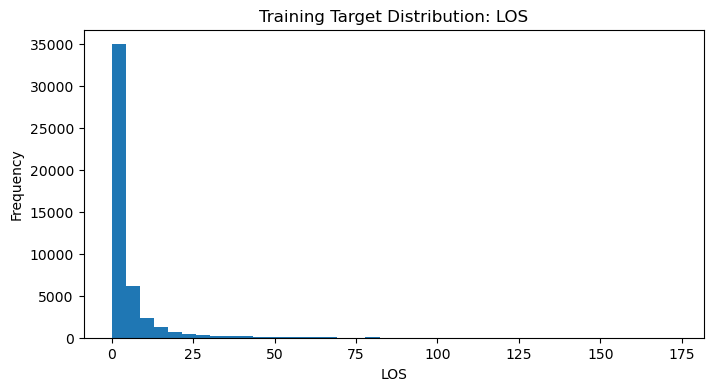

count    47333.000000
mean         5.023395
std          9.721905
min          0.014400
25%          1.150500
50%          2.143900
75%          4.645100
max        173.072500
Name: LOS, dtype: float64

In [ ]:
# Target distribution overview

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_df[TARGET_COL], bins=40)
ax.set_title("Training Target Distribution: LOS")
ax.set_xlabel("LOS")
ax.set_ylabel("Frequency")
plt.show()

train_df[TARGET_COL].describe()

#### Optional target transformation

ICU Length of Stay is often right-skewed.  
That means a log transformation can sometimes improve stability for linear and boosting models.

This notebook keeps the **original target** as the default setup, because evaluation on the original LOS scale is easier to explain.  
However, an optional `log1p` configuration is included below. You can activate it if needed and compare both versions.

In [ ]:
# ===================================
# Optional target transformation flag
# ===================================

USE_LOG_TARGET = False

if USE_LOG_TARGET:
    y_train_full = np.log1p(train_df[TARGET_COL].copy())
    y_test = np.log1p(test_df[TARGET_COL].copy())
    print("Using log1p(LOS) as target.")
else:
    y_train_full = train_df[TARGET_COL].copy()
    y_test = test_df[TARGET_COL].copy()
    print("Using original LOS as target.")

Using original LOS as target.


### Feature and Target Definition

The final model must **not** use:

- `LOS` (the target),
- `SUBJECT_ID`,
- `HADM_ID`,
- `ICUSTAY_ID`.

These identifiers are important for traceability and leakage-safe validation, but they should be excluded from the feature matrix.

As the dataset is already numerically encoded, we will treat all remaining columns as model features.

In [ ]:
# Feature and Target Definition

feature_cols = [c for c in train_df.columns if c not in ID_COLS + [TARGET_COL]]

X_train_full = train_df[feature_cols].copy()
X_test = test_df[feature_cols].copy()

y_train_full = train_df[TARGET_COL].copy()
y_test = test_df[TARGET_COL].copy()

groups = train_df["SUBJECT_ID"].copy()

print("Number of features:", len(feature_cols))
print("X_train shape:", X_train_full.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train_full.shape)
print("y_test shape: ", y_test.shape)

# Sanity check: all feature columns should exist in test set
assert list(X_train_full.columns) == list(X_test.columns), "Train and test feature columns do not match."

# Most prepared versions of the dataset should already be numeric, but this confirms the assumption.
non_numeric_cols = X_train_full.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()
print("Non-numeric feature columns:", len(non_numeric_cols))
non_numeric_cols[:20]

Number of features: 776
X_train shape: (47333, 776)
X_test shape:  (11792, 776)
y_train shape: (47333,)
y_test shape:  (11792,)
Non-numeric feature columns: 0


[]

### Cross-Validation Strategy

We use **GroupKFold** with `SUBJECT_ID` as the grouping variable to **prevent patient leakage** during cross-validation. Although each row represents a single ICU stay (`ICUSTAY_ID`), the same patient may appear multiple times in the training set through different stays. Without grouped validation, one stay from a patient could be used for training while another stay from the same patient could appear in validation, leading to overly optimistic performance estimates. GroupKFold ensures that all stays from the same patient remain in the same fold.


In [ ]:
train_subjects = set(train_df["SUBJECT_ID"].unique())
test_subjects = set(test_df["SUBJECT_ID"].unique())

overlap = train_subjects.intersection(test_subjects)

print("Train subjects:", len(train_subjects))
print("Test subjects:", len(test_subjects))
print("Overlap:", len(overlap))

Train subjects: 35992
Test subjects: 8998
Overlap: 0


In [ ]:
train_stays_per_subject = train_df.groupby("SUBJECT_ID")["ICUSTAY_ID"].nunique()

print("Subjects with >1 ICU stay in train:", (train_stays_per_subject > 1).sum())
print("Max ICU stays for one subject:", train_stays_per_subject.max())

Subjects with >1 ICU stay in train: 6622
Max ICU stays for one subject: 41


In [ ]:
# Cross-Validation Strategy

gkf = GroupKFold(n_splits=N_SPLITS)

cv_preview = []
for fold, (tr_idx, va_idx) in enumerate(gkf.split(X_train_full, y_train_full, groups=groups), start=1):
    train_subjects = set(groups.iloc[tr_idx])
    valid_subjects = set(groups.iloc[va_idx])
    overlap = len(train_subjects.intersection(valid_subjects))
    cv_preview.append({
        "fold": fold,
        "train_rows": len(tr_idx),
        "valid_rows": len(va_idx),
        "train_subjects": len(train_subjects),
        "valid_subjects": len(valid_subjects),
        "subject_overlap": overlap
    })

cv_preview_df = pd.DataFrame(cv_preview)
display(cv_preview_df)

,fold,train_rows,valid_rows,train_subjects,valid_subjects,subject_overlap
0,1,37866,9467,28794,7198,0
1,2,37866,9467,28793,7199,0
2,3,37866,9467,28793,7199,0
3,4,37867,9466,28794,7198,0
4,5,37867,9466,28794,7198,0


### Baseline Models

The first step is to compare a **small, defensible set of baseline models**.
The model set was intentionally chosen to cover different levels of complexity and inductive bias, ranging from a trivial baseline to regularized linear modelling and more expressive non-linear ensemble methods:

1. **DummyRegressor** — included as a minimal baseline to establish the performance of a trivial prediction strategy and verify that the trained models provide meaningful predictive value beyond naive central-tendency estimates.  
2. **Ridge** — included as a regularized linear baseline, particularly suitable for high-dimensional tabular data with potentially correlated predictors, while also offering a relatively interpretable reference model.  
3. **RandomForestRegressor** — included as a non-linear ensemble method capable of modelling complex interactions and non-linear relationships between features without strong distributional assumptions.  
4. **HistGradientBoostingRegressor** — included as a strong boosting-based baseline for tabular data, combining competitive predictive performance with computational efficiency on medium-to-large structured datasets.

In [ ]:
# Baseline Models

models = {
    "Dummy": Pipeline([
        ("model", DummyRegressor(strategy="mean"))
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE))
    ]),
    "RandomForest": Pipeline([
        ("model", RandomForestRegressor(
            n_estimators=250,
            max_depth=None,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
    "HistGradientBoosting": Pipeline([
        ("model", HistGradientBoostingRegressor(
            learning_rate=0.05,
            max_depth=None,
            max_iter=250,
            random_state=RANDOM_STATE
        ))
    ]),
}

### Cross-Validated Benchmarking

This section benchmarks the candidate models using **GroupKFold** on the training set.

The scoring metrics are:

- **MAE** — used as the main metric because it is directly interpretable in the original unit of the target variable (days of ICU stay). It measures the average absolute prediction error and provides a clear sense of how far predictions are from the true LOS on average. 
- **RMSE** — included because it penalizes large errors more strongly than MAE, making it useful for detecting whether a model performs poorly on extreme or long-stay cases, which are particularly relevant in this dataset due to the strong right-skew of LOS.
- **R²** — included as a complementary goodness-of-fit measure, indicating how much of the variability in LOS is explained by the model relative to a naive mean-based predictor. It is useful for comparing overall explanatory power, although it is less directly interpretable than error-based metrics.
- **Median Absolute Error** — included as a robust summary of typical prediction error, less sensitive to extreme outliers than MAE or RMSE. This is particularly important in LOS prediction because a small number of very long ICU stays can distort average-based error measures. 

In [ ]:
# Memory optimization
X_train_full = X_train_full.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train_full = y_train_full.astype(np.float32)
y_test = y_test.astype(np.float32)

In [ ]:
# Cross-Validated Benchmarking
cv_results_path = os.path.join(RESULTS_DIR, "baseline_cv_results.csv")

if os.path.exists(cv_results_path):
    print(f"Loading existing CV results from: {cv_results_path}")
    cv_results_df = pd.read_csv(cv_results_path)
else:
    print("No saved CV results found. Running cross-validation...")

    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
        "medae": "neg_median_absolute_error"
    }

    cv_results = []

    for name, pipeline in models.items():
        print(f"Running grouped CV for {name}...")
        start = time.time()

        scores = cross_validate(
            pipeline,
            X_train_full,
            y_train_full,
            groups=groups,
            cv=gkf,
            scoring=scoring,
            return_train_score=False,
            n_jobs=1
        )

        elapsed = time.time() - start

        cv_results.append({
            "model": name,
            "cv_mae_mean": -scores["test_mae"].mean(),
            "cv_mae_std": scores["test_mae"].std(),
            "cv_rmse_mean": -scores["test_rmse"].mean(),
            "cv_rmse_std": scores["test_rmse"].std(),
            "cv_r2_mean": scores["test_r2"].mean(),
            "cv_r2_std": scores["test_r2"].std(),
            "cv_medae_mean": -scores["test_medae"].mean(),
            "fit_time_seconds": elapsed
        })

    cv_results_df = pd.DataFrame(cv_results).sort_values("cv_mae_mean").reset_index(drop=True)

    os.makedirs(RESULTS_DIR, exist_ok=True)
    cv_results_df.to_csv(cv_results_path, index=False)
    print(f"Saved: {cv_results_path}")

display(cv_results_df)

Loading existing CV results from: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\results\baseline_cv_results.csv


,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,cv_medae_mean,fit_time_seconds
0,HistGradientBoosting,3.439322,0.052658,7.650147,0.198067,0.379478,0.017474,1.578232,144.803396
1,RandomForest,3.532526,0.038803,7.783500,0.137058,0.357192,0.025321,1.450010,4077.973721
2,Ridge,3.998749,0.210949,15.143467,14.043787,-3.346799,7.278591,1.921106,3.149978
3,Dummy,4.776248,0.058067,9.716469,0.327570,-0.000110,0.000128,3.410546,0.527098


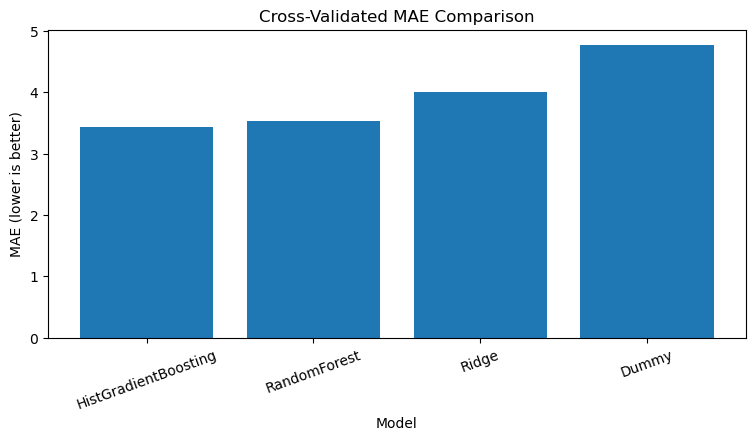

In [ ]:
# Quick visualization of CV comparison

fig, ax = plt.subplots(figsize=(9, 4))
ordered = cv_results_df.sort_values("cv_mae_mean")
ax.bar(ordered["model"], ordered["cv_mae_mean"])
ax.set_title("Cross-Validated MAE Comparison")
ax.set_ylabel("MAE (lower is better)")
ax.set_xlabel("Model")
plt.xticks(rotation=20)
plt.show()

### Fit Baseline Models and Evaluate on Test Set

After selecting candidate models through cross-validation, each baseline model is fitted on the **full training data** and evaluated on the held-out **test set**.

In [ ]:
USE_LOG_TARGET = False  # Keep False if models were trained on raw LOS values

def maybe_inverse_target(values):
    """
    Invert the target transformation only if log1p(LOS) was used during training.
    """
    values = np.asarray(values)
    if USE_LOG_TARGET:
        return np.expm1(values)
    return values

def regression_metrics(y_true, y_pred):
    """
    Compute regression metrics in the original LOS scale.
    """
    y_true_eval = maybe_inverse_target(y_true)
    y_pred_eval = maybe_inverse_target(y_pred)

    return {
        "MAE": mean_absolute_error(y_true_eval, y_pred_eval),
        "RMSE": mean_squared_error(y_true_eval, y_pred_eval, squared=False),
        "R2": r2_score(y_true_eval, y_pred_eval),
        "MedianAE": median_absolute_error(y_true_eval, y_pred_eval)
    }


# Fit baseline models on the full training set and evaluate on test set

FORCE_RERUN_BASELINE_TEST = False

test_results_path = os.path.join(RESULTS_DIR, "baseline_test_results.csv")
predictions_path = os.path.join(RESULTS_DIR, "baseline_test_predictions.csv")

model_paths = {
    name: os.path.join(MODELS_DIR, f"{name.lower()}_baseline.joblib")
    for name in models.keys()
}

all_model_files_exist = all(os.path.exists(path) for path in model_paths.values())
all_outputs_exist = (
    os.path.exists(test_results_path)
    and os.path.exists(predictions_path)
    and all_model_files_exist
)

if all_outputs_exist and not FORCE_RERUN_BASELINE_TEST:
    print("Loading existing baseline test evaluation artifacts...")

    test_results_df = pd.read_csv(test_results_path)
    baseline_predictions = pd.read_csv(predictions_path)

    fitted_models = {}
    for name, model_path in model_paths.items():
        fitted_models[name] = joblib.load(model_path)
        print(f"Loaded model: {model_path}")

else:
    print("No complete saved baseline artifacts found. Running baseline training and test evaluation...")

    fitted_models = {}
    test_results = []

    # Store test predictions for later analysis (scatter plots, residuals, etc.)
    baseline_predictions = pd.DataFrame({
        "SUBJECT_ID": test_df["SUBJECT_ID"].values,
        "HADM_ID": test_df["HADM_ID"].values,
        "ICUSTAY_ID": test_df["ICUSTAY_ID"].values,
        "y_true": maybe_inverse_target(y_test.to_numpy())
    })

    for name, pipeline in models.items():
        print(f"Fitting {name}...")

        model = clone(pipeline)

        start = time.time()
        model.fit(X_train_full, y_train_full)
        fit_seconds = time.time() - start

        preds = model.predict(X_test)
        metrics = regression_metrics(y_test, preds)

        metrics["model"] = name
        metrics["fit_time_seconds"] = fit_seconds

        fitted_models[name] = model
        test_results.append(metrics)

        # Save predictions in the original target scale
        baseline_predictions[f"{name}_pred"] = maybe_inverse_target(preds)

    # Build results table
    test_results_df = pd.DataFrame(test_results).sort_values("MAE").reset_index(drop=True)

    # Save outputs
    os.makedirs(RESULTS_DIR, exist_ok=True)
    os.makedirs(MODELS_DIR, exist_ok=True)

    test_results_df.to_csv(test_results_path, index=False)
    print(f"Saved: {test_results_path}")

    baseline_predictions.to_csv(predictions_path, index=False)
    print(f"Saved: {predictions_path}")

    for name, model in fitted_models.items():
        model_filename = f"{name.lower()}_baseline.joblib"
        model_path = os.path.join(MODELS_DIR, model_filename)
        joblib.dump(model, model_path)
        print(f"Saved: {model_path}")

display(test_results_df)

Loading existing baseline test evaluation artifacts...
Loaded model: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\models\dummy_baseline.joblib
Loaded model: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\models\ridge_baseline.joblib
Loaded model: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\models\randomforest_baseline.joblib
Loaded model: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\models\histgradientboosting_baseline.joblib


,MAE,RMSE,R2,MedianAE,model,fit_time_seconds
0,3.273359,7.191070,0.369040,1.392142,HistGradientBoosting,44.150623
1,3.444649,7.317351,0.346685,1.411422,RandomForest,780.411691
2,3.820191,7.625561,0.290490,1.868881,Ridge,0.623009
3,4.720606,9.053645,-0.000143,3.456896,Dummy,0.000000


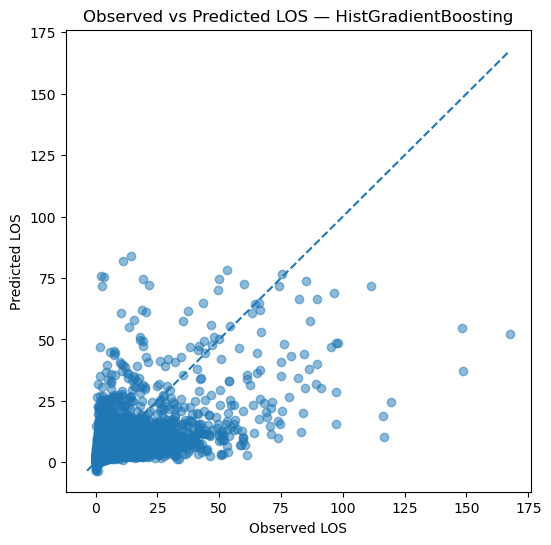

In [ ]:
# Observed vs predicted scatter for the best baseline model

best_baseline_name = test_results_df.iloc[0]["model"]
best_baseline_model = fitted_models[best_baseline_name]
best_baseline_preds = maybe_inverse_target(best_baseline_model.predict(X_test))
y_test_eval = maybe_inverse_target(y_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_eval, best_baseline_preds, alpha=0.5)
line_min = min(np.min(y_test_eval), np.min(best_baseline_preds))
line_max = max(np.max(y_test_eval), np.max(best_baseline_preds))
ax.plot([line_min, line_max], [line_min, line_max], linestyle="--")
ax.set_title(f"Observed vs Predicted LOS — {best_baseline_name}")
ax.set_xlabel("Observed LOS")
ax.set_ylabel("Predicted LOS")
plt.show()

### Hyperparameter Tuning with Optuna

At this point, a baseline ranking already exists.  
Only the strongest candidates should be tuned:
- `Ridge`
- `HistGradientBoostingRegressor`

In [ ]:
# Hyperparameter Tuning with Optuna

TOP_MODELS_TO_TUNE = ["HistGradientBoosting", "RandomForest"]
N_TRIALS = 30
FORCE_RERUN_OPTUNA = False

optuna_results_path = os.path.join(RESULTS_DIR, "optuna_results.csv")

In [ ]:
# Helper functions for Optuna tuning

def evaluate_cv_pipeline(pipeline, X, y, groups):
    """
    Evaluate a pipeline with grouped cross-validation using MAE as
    the optimization objective.
    """
    scores = cross_validate(
        pipeline,
        X,
        y,
        groups=groups,
        cv=gkf,
        scoring={"mae": "neg_mean_absolute_error"},
        n_jobs=1,
        return_train_score=False
    )
    return -scores["test_mae"].mean()

def build_hgb_pipeline(
    learning_rate,
    max_depth,
    max_iter,
    min_samples_leaf,
    l2_regularization
):
    return Pipeline([
        ("model", HistGradientBoostingRegressor(
            learning_rate=learning_rate,
            max_depth=max_depth,
            max_iter=max_iter,
            min_samples_leaf=min_samples_leaf,
            l2_regularization=l2_regularization,
            random_state=RANDOM_STATE
        ))
    ])

def build_rf_pipeline(
    n_estimators,
    max_depth,
    min_samples_leaf,
    max_features
):
    return Pipeline([
        ("model", RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])


In [ ]:
# Run Optuna studies

optuna_summaries = []
studies = {}

if OPTUNA_AVAILABLE:

    if os.path.exists(optuna_results_path) and not FORCE_RERUN_OPTUNA:
        print(f"Loading existing Optuna results from: {optuna_results_path}")
        optuna_results_df = pd.read_csv(optuna_results_path)
        display(optuna_results_df)

    else:
        print("Running Optuna studies...")

        def hgb_objective(trial):
            learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
            max_depth = trial.suggest_int("max_depth", 3, 12)
            max_iter = trial.suggest_int("max_iter", 100, 400)
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 10, 80)
            l2_regularization = trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True)

            pipeline = build_hgb_pipeline(
                learning_rate=learning_rate,
                max_depth=max_depth,
                max_iter=max_iter,
                min_samples_leaf=min_samples_leaf,
                l2_regularization=l2_regularization
            )
            return evaluate_cv_pipeline(pipeline, X_train_full, y_train_full, groups)

        def rf_objective(trial):
            n_estimators = trial.suggest_int("n_estimators", 100, 400, step=50)
            max_depth = trial.suggest_int("max_depth", 5, 30)
            min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
            max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5, 0.8])

            pipeline = build_rf_pipeline(
                n_estimators=n_estimators,
                max_depth=max_depth,
                min_samples_leaf=min_samples_leaf,
                max_features=max_features
            )
            return evaluate_cv_pipeline(pipeline, X_train_full, y_train_full, groups)

        if "HistGradientBoosting" in TOP_MODELS_TO_TUNE:
            print("Tuning HistGradientBoosting...")
            hgb_study = optuna.create_study(direction="minimize", study_name="hgb_mae")
            hgb_study.optimize(hgb_objective, n_trials=N_TRIALS, show_progress_bar=False)
            studies["HistGradientBoosting"] = hgb_study
            optuna_summaries.append({
                "model": "HistGradientBoosting",
                "best_cv_mae": hgb_study.best_value,
                "best_params": str(hgb_study.best_params)
            })

        if "RandomForest" in TOP_MODELS_TO_TUNE:
            print("Tuning RandomForest...")
            rf_study = optuna.create_study(direction="minimize", study_name="rf_mae")
            rf_study.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=False)
            studies["RandomForest"] = rf_study
            optuna_summaries.append({
                "model": "RandomForest",
                "best_cv_mae": rf_study.best_value,
                "best_params": str(rf_study.best_params)
            })

        optuna_results_df = pd.DataFrame(optuna_summaries).sort_values("best_cv_mae").reset_index(drop=True)
        display(optuna_results_df)

        os.makedirs(RESULTS_DIR, exist_ok=True)
        optuna_results_df.to_csv(optuna_results_path, index=False)
        print(f"Saved: {optuna_results_path}")

else:
    optuna_results_df = pd.DataFrame()
    print("Skipping Optuna section because Optuna is unavailable.")

Loading existing Optuna results from: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\results\optuna_results.csv


,model,best_cv_mae,best_params
0,RandomForest,3.347623,"{'n_estimators': 300, 'max_depth': 28, 'min_sa..."
1,HistGradientBoosting,3.370540,"{'learning_rate': 0.059504219719087904, 'max_d..."


### Final Model Training and Test Evaluation

This section rebuilds the tuned models from their best parameters, trains them on the full training set, and evaluates them on the held-out test set.

The tuned results can then be compared directly against the baseline benchmark.

In [ ]:
tuned_models = {}
tuned_test_results = []

# Store tuned-model predictions for later analysis
tuned_predictions = pd.DataFrame({
    "SUBJECT_ID": test_df["SUBJECT_ID"].values,
    "HADM_ID": test_df["HADM_ID"].values,
    "ICUSTAY_ID": test_df["ICUSTAY_ID"].values,
    "y_true": maybe_inverse_target(y_test.to_numpy())
})

if OPTUNA_AVAILABLE and not optuna_results_df.empty:

    # Convert best_params from string back to dictionary if needed
    optuna_results_df = optuna_results_df.copy()
    optuna_results_df["best_params"] = optuna_results_df["best_params"].apply(
        lambda x: ast.literal_eval(x) if isinstance(x, str) else x
    )

    if "HistGradientBoosting" in optuna_results_df["model"].values:
        hgb_params = optuna_results_df.loc[
            optuna_results_df["model"] == "HistGradientBoosting", "best_params"
        ].iloc[0]

        tuned_models["HistGradientBoosting_Tuned"] = build_hgb_pipeline(
            learning_rate=hgb_params["learning_rate"],
            max_depth=hgb_params["max_depth"],
            max_iter=hgb_params["max_iter"],
            min_samples_leaf=hgb_params["min_samples_leaf"],
            l2_regularization=hgb_params["l2_regularization"]
        )

    if "RandomForest" in optuna_results_df["model"].values:
        rf_params = optuna_results_df.loc[
            optuna_results_df["model"] == "RandomForest", "best_params"
        ].iloc[0]

        tuned_models["RandomForest_Tuned"] = build_rf_pipeline(
            n_estimators=rf_params["n_estimators"],
            max_depth=rf_params["max_depth"],
            min_samples_leaf=rf_params["min_samples_leaf"],
            max_features=rf_params["max_features"]
        )

    for name, pipeline in tuned_models.items():
        print(f"Fitting tuned model: {name}...")

        start = time.time()
        pipeline.fit(X_train_full, y_train_full)
        fit_seconds = time.time() - start

        preds = pipeline.predict(X_test)
        metrics = regression_metrics(y_test, preds)

        metrics["model"] = name
        metrics["fit_time_seconds"] = fit_seconds
        tuned_test_results.append(metrics)

        tuned_predictions[f"{name}_pred"] = maybe_inverse_target(preds)

        # Save fitted tuned model
        os.makedirs(MODELS_DIR, exist_ok=True)
        model_path = os.path.join(MODELS_DIR, f"{name.lower()}.joblib")
        joblib.dump(pipeline, model_path)
        print(f"Saved: {model_path}")

else:
    print("Skipping tuned model evaluation because Optuna results are unavailable.")

# Build results table
tuned_test_results_df = (
    pd.DataFrame(tuned_test_results).sort_values("MAE").reset_index(drop=True)
    if tuned_test_results
    else pd.DataFrame()
)

display(tuned_test_results_df)

# Save outputs
if not tuned_test_results_df.empty:
    os.makedirs(RESULTS_DIR, exist_ok=True)

    tuned_results_path = os.path.join(RESULTS_DIR, "tuned_test_results.csv")
    tuned_preds_path = os.path.join(RESULTS_DIR, "tuned_test_predictions.csv")

    tuned_test_results_df.to_csv(tuned_results_path, index=False)
    tuned_predictions.to_csv(tuned_preds_path, index=False)

    print(f"Saved: {tuned_results_path}")
    print(f"Saved: {tuned_preds_path}")

Fitting tuned model: HistGradientBoosting_Tuned...
Saved: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\models\histgradientboosting_tuned.joblib
Fitting tuned model: RandomForest_Tuned...
Saved: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\models\randomforest_tuned.joblib


,MAE,RMSE,R2,MedianAE,model,fit_time_seconds
0,3.254083,7.076414,0.389000,1.386170,HistGradientBoosting_Tuned,42.391899
1,3.265030,7.041184,0.395068,1.383268,RandomForest_Tuned,274.956573


Saved: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\results\tuned_test_results.csv
Saved: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\results\tuned_test_predictions.csv


In [ ]:
FORCE_RERUN_FINAL_COMPARISON = False

final_comparison_path = os.path.join(RESULTS_DIR, "final_model_comparison.csv")

if os.path.exists(final_comparison_path) and not FORCE_RERUN_FINAL_COMPARISON:
    print(f"Loading existing final comparison from: {final_comparison_path}")
    final_comparison_df = pd.read_csv(final_comparison_path)

else:
    print("Building consolidated model comparison...")

    frames_to_concat = []

    if 'test_results_df' in globals() and not test_results_df.empty:
        frames_to_concat.append(test_results_df.copy())

    if 'tuned_test_results_df' in globals() and not tuned_test_results_df.empty:
        frames_to_concat.append(tuned_test_results_df.copy())

    if len(frames_to_concat) == 0:
        final_comparison_df = pd.DataFrame()
        print("No model result tables were available for consolidation.")
    else:
        final_comparison_df = (
            pd.concat(frames_to_concat, ignore_index=True)
            .sort_values("MAE")
            .reset_index(drop=True)
        )

        os.makedirs(RESULTS_DIR, exist_ok=True)
        final_comparison_df.to_csv(final_comparison_path, index=False)
        print(f"Saved: {final_comparison_path}")

display(final_comparison_df)

Building consolidated model comparison...
Saved: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\results\final_model_comparison.csv


,MAE,RMSE,R2,MedianAE,model,fit_time_seconds
0,3.254083,7.076414,0.389000,1.386170,HistGradientBoosting_Tuned,42.391899
1,3.265030,7.041184,0.395068,1.383268,RandomForest_Tuned,274.956573
2,3.273359,7.191070,0.369040,1.392142,HistGradientBoosting,44.150623
3,3.444649,7.317351,0.346685,1.411422,RandomForest,780.411691
4,3.820191,7.625561,0.290490,1.868881,Ridge,0.623009
5,4.720606,9.053645,-0.000143,3.456896,Dummy,0.000000


### Model Interpretation

In this project, the final comparison includes both baseline and tuned models, and interpretation is therefore performed only for the top-ranked model after test-set evaluation.

For linear models such as **Ridge**, coefficients can be interpreted directly.  
For non-linear ensemble models such as **Random Forest** or **HistGradientBoosting**, **permutation importance** provides a more appropriate and model-agnostic interpretation method.

In [ ]:
# Model Interpretation

FORCE_RERUN_IMPORTANCE = False

importance_path = os.path.join(RESULTS_DIR, "permutation_importance.csv")

# Select the best available model: tuned if available, otherwise best baseline
if 'final_comparison_df' in globals() and not final_comparison_df.empty:
    best_model_name = final_comparison_df.iloc[0]["model"]
elif 'tuned_test_results_df' in globals() and not tuned_test_results_df.empty:
    best_model_name = tuned_test_results_df.iloc[0]["model"]
else:
    best_model_name = test_results_df.iloc[0]["model"]

# Recover the fitted best model
if 'tuned_models' in globals() and best_model_name in tuned_models:
    best_model = tuned_models[best_model_name]
elif 'fitted_models' in globals() and best_model_name in fitted_models:
    best_model = fitted_models[best_model_name]
else:
    raise ValueError(f"Best model '{best_model_name}' was not found in fitted model dictionaries.")

print("Best model selected for interpretation:", best_model_name)

if os.path.exists(importance_path) and not FORCE_RERUN_IMPORTANCE:
    print(f"Loading existing permutation importance from: {importance_path}")
    importance_df = pd.read_csv(importance_path)

else:
    print("Computing permutation importance...")

    start = time.time()
    perm = permutation_importance(
        best_model,
        X_test,
        y_test,
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=1
    )
    elapsed = time.time() - start

    importance_df = pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False).reset_index(drop=True)

    print(f"Permutation importance computed in {elapsed:.2f} seconds.")

    os.makedirs(RESULTS_DIR, exist_ok=True)
    importance_df.to_csv(importance_path, index=False)
    print(f"Saved: {importance_path}")

display(importance_df.head(20))

Best model selected for interpretation: HistGradientBoosting_Tuned
Computing permutation importance...
Permutation importance computed in 1398.97 seconds.
Saved: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\results\permutation_importance.csv


,feature,importance_mean,importance_std
0,item_834_count,0.287344,0.009425
1,item_834_mean,0.024849,0.004460
2,LAST_CAREUNIT_SICU,0.023592,0.001151
3,item_723_last,0.021394,0.001058
4,item_211_mean,0.021321,0.002009
5,ADMISSION_LOCATION_CLINIC REFERRAL/PREMATURE,0.020798,0.002716
6,item_113_min,0.018701,0.005018
7,FIRST_CAREUNIT_SICU,0.017650,0.000815
8,item_211_count,0.017631,0.001406
9,item_223900_last,0.016502,0.000797


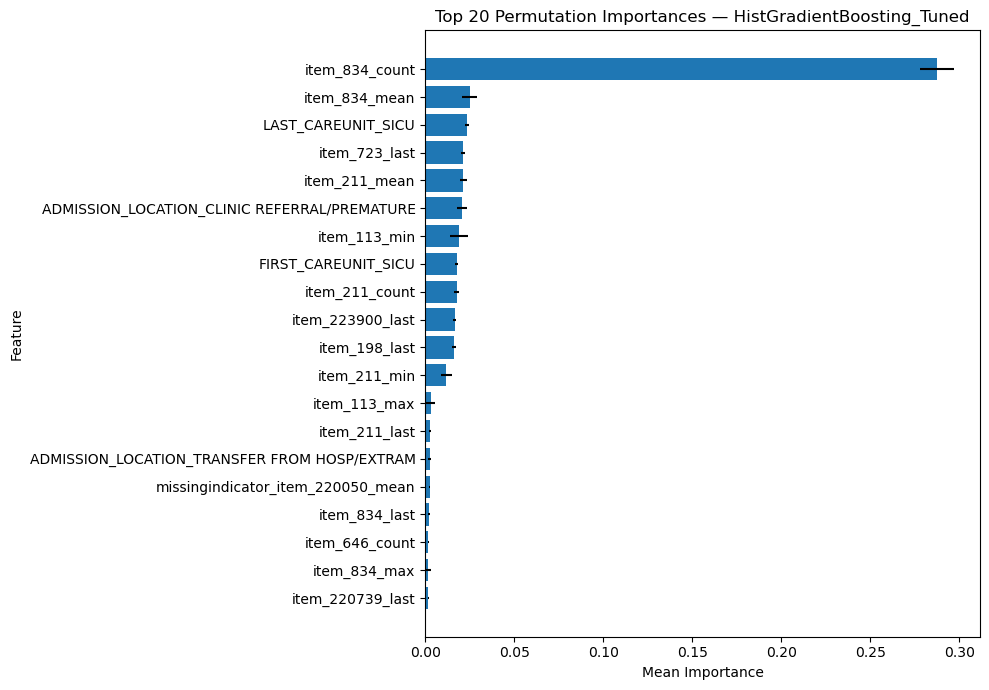

In [ ]:
top_k = 20
top_importance = (
    importance_df.sort_values("importance_mean", ascending=False)
    .head(top_k)
    .sort_values("importance_mean")
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"]
)
ax.set_title(f"Top {top_k} Permutation Importances — {best_model_name}")
ax.set_xlabel("Mean Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

### Save Results and Artifacts

A professional training workflow should persist its results.

This section saves:

- baseline CV results,
- baseline test results,
- final comparison table,
- permutation importances,
- and the final selected model.

In [ ]:
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

# Determine best final model
best_final_name = final_comparison_df.iloc[0]["model"]
best_final_model = tuned_models.get(best_final_name, fitted_models.get(best_final_name))

# Save best model
model_filename = f"{best_final_name.lower().replace(' ', '_')}.joblib"
model_path = os.path.join(MODELS_DIR, model_filename)
joblib.dump(best_final_model, model_path)

# Save run summary
summary_payload = {
    "best_model": best_final_name,
    "use_log_target": USE_LOG_TARGET,
    "n_features": len(feature_cols),
    "train_shape": list(train_df.shape),
    "test_shape": list(test_df.shape),
    "results_file": os.path.join(RESULTS_DIR, "final_model_comparison.csv"),
    "importance_file": os.path.join(RESULTS_DIR, "permutation_importance.csv"),
    "saved_model": model_path
}

summary_path = os.path.join(RESULTS_DIR, "run_summary.json")
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary_payload, f, indent=2)

print("Saved model:", model_path)
print("Saved run summary:", summary_path)

Saved model: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\models\histgradientboosting_tuned.joblib
Saved run summary: C:\Users\leono\Documents\ICU-LengthOfStay-Prediction\results\run_summary.json
